# Notebook to investigate House Prices Tutorial Competition

In this notebook, I look into the tutorial competition for predicting house prices

## Code from Kaggle

The cell below was automatically generated when I created a new notebook. Let's ignore it for now

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
input_dir = '../input/'  # Use './' for submission
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a
# version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

../input/house-prices-advanced-regression-techniques/test.csv
../input/house-prices-advanced-regression-techniques/data_description.txt
../input/house-prices-advanced-regression-techniques/train.csv
../input/house-prices-advanced-regression-techniques/sample_submission.csv


## Exploratory Data Analysis (EPA)

Let's dedicate some time to understand the data first.

### Getting features

We will get the features from the `data_description.txt` file first, as they will help us distinguish between continuous and categorical features, as well as help read in the data.

In [2]:
with open(input_dir + 'house-prices-advanced-regression-techniques/data_description.txt', 'r') as data_description_file:
    raw_desc_lines = data_description_file.readlines()  # Read all lines
    data_description_file.close()

print(f'Read in {len(raw_desc_lines)} lines')

Read in 523 lines


Let's clean up the lines a bit to remove all blank lines.

In [3]:
dense_desc_lines = [line for line in raw_desc_lines if len(line.strip('\n \t')) != 0]
print(f'Obtained {len(dense_desc_lines)} information-rich lines.')

Obtained 399 information-rich lines.


The categorical features will have the categories specified in the subsequent lines, while the continuous features occuply only one line. 

In [4]:
# Prepare a dictionary to store the features we find
features_info = {'continuous': [],
                 'categorical': {}}

# Let's go through the lines and add them to the features
line_number = 0

# Auxiliary variable to tell us if we are reading a category from a feature
reading_category = False
last_cat_feature = None

while line_number < len(dense_desc_lines):
    # Get the content
    line_content = dense_desc_lines[line_number]

    # If we are not currently reading a feature
    if (line_content.lstrip(' ') == line_content):
        feat_name = line_content.split(':')[0]
        # Check if the next line starts with a space
        next_line_number = line_number + 1
        if next_line_number == len(dense_desc_lines):  # reached EOF in a continous feature
            features_info['continuous'].append(feat_name)
            break
        next_line = dense_desc_lines[next_line_number]
        # If the next line starts with a space, we have a category
        if next_line[0] == ' ':
            last_cat_feature = feat_name
            features_info['categorical'][last_cat_feature] = {}
            reading_category = True
        # Otherwise, it's a continuous feature
        else:
            features_info['continuous'].append(feat_name)
            reading_category = False

    # If we are reading a category, let's make sure we process it correctly
    else:
        cat = line_content.split('\t')[0].strip(' ')
        cat_desc = line_content.split('\t')[1].strip(' \n')
        features_info['categorical'][last_cat_feature][cat] = cat_desc

    # Go to next line
    line_number += 1

In [5]:
print(f"Found {len(features_info['continuous'])} continous features")
print(f"Found {len(features_info['categorical'])} categorical features")

Found 33 continous features
Found 46 categorical features


Ok, so we retrieved the features correctly, as there are 79 of them (the original table had 81 columns, including `'Id'` and the target variable)

I happen to know there is a small issue in the continuous features: the `'Bedroom'` and `'Kitchen'` are called something different in the data. Let's fix that by hand.

In [6]:
bed_id = features_info['continuous'].index('Bedroom')
kit_id = features_info['continuous'].index('Kitchen')

features_info['continuous'][bed_id] = 'BedroomAbvGr'
features_info['continuous'][kit_id] = 'KitchenAbvGr'

### Reading in data

First, let's make sure that, for the continuous features, strings like `' '`, `'NA'`, `'N/A'`, `'NULL'`, etc. are properly interpreted as `NaN`. For the categorical features, we need to make sure those are considered separate categories.

In [7]:
na_values = dict.fromkeys(features_info['continuous'], [' ', 'NA', 'N/A', 'Null', 'NULL'])

full_training = pd.read_csv(input_dir + 'house-prices-advanced-regression-techniques/train.csv',
                            keep_default_na=False,  # Recall some of the categories are 'NA'
                            na_values=na_values,
                            )
num_entries = full_training.shape[0]

print(f'Total number of entries in traning data = {num_entries}')

full_training.head(5)

Total number of entries in traning data = 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000


We can immediately see there are a lot of features here, some categorical (such as the `'MSZoning'`), and some continuous (such as the `'LotArea'`).

Recall the target variable is the sale price.

In [8]:
target_name = 'SalePrice'

### Just a hunch plot

Let's plot a few variables 

In [9]:
import matplotlib.pyplot as plt

We will first do a naive one: plot the target variable as a function of the lot area/size, and color it based on the zone class.

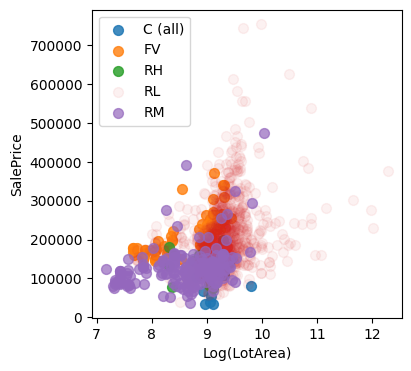

In [10]:
# Specify variables
continuous_var = 'LotArea'
categorical_var = 'MSZoning'

# Plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel(target_name)
ax.set_xlabel(f'Log({continuous_var})')

for zone, hunch_data in full_training.groupby(categorical_var):
    sc = ax.scatter(np.log(hunch_data[continuous_var]), hunch_data[target_name],
                    # color=colors[zone],
                    marker='o',
                    alpha=(0.85 - len(hunch_data)/num_entries),  # The more entries the lighter for visualization purposes
                    s=50,
                    label=zone)
    # sc.set_facecolor("none")

_ = ax.legend()

The distribution of the target price appears to be not normal. Let's take a quick look.

### Target variable

Start by defining a helpful function to do this for us.

In [11]:
from typing import Dict

from matplotlib.figure import Figure
from matplotlib.axes import Axes

def view_stats(data: pd.Series,
               axes: Axes, 
               scale: float = 1.0,
               bins: int = 30,
               color: str = 'blue',
               alpha: float = 1.0,
               verbose: bool = True) -> Dict:
    """
    Auxiliary function to plot and compute helpful statistics of a certain column in the dataframe

    Args:
        data: Series of data to be used
        axes: axes to be used when plotting the histogram
        scale: scale value to apply before computing statistics; defaults to 1.
        bins: number of bins to be used in histogram plot; defaults to 30
        color: color to be used; defaults to blue
        alpha: opacity to be used; defaults to 1.0 (fully opaque)
        verbose: flag to indicate whether to print statistics or not; defaults to True

    Returns:
        a dictionary containining statistics
    """
    # Compute stats
    median = (scale * data).median()
    mean = (scale * data).mean()
    std = (scale * data).std()
    skew = (scale * data).skew()
    kurtosis = (scale * data).kurtosis()

    # Store in dict
    stats = {'median': median,
             'mean': mean,
             'std': std,
             'skew': skew,
             'kurtosis': kurtosis,
             'pre_scale': scale}

    # Plot
    (data * scale).hist(bins=bins, ax=axes, color=color, alpha=alpha)

    # Print info
    if verbose:
        for key, val in stats.items():
            print(f'{key.upper()}: {val}')

    return stats

Now, let's plot the values, but scale them down so we are dealing with "units" of a thousand dollars.

MEDIAN: 163.0
MEAN: 180.92119589041096
STD: 79.4425028828866
SKEW: 1.8828757597682129
KURTOSIS: 6.5362818600645305
PRE_SCALE: 0.001


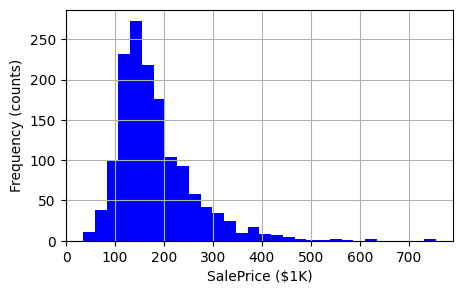

In [12]:
# Define the scaling parameter
scale=1.0e-03

# Create figure
fig, axes = plt.subplots(figsize=(5, 3))

target_stats = view_stats(data=full_training[target_name], axes=axes, scale=scale)
axes.set_xlabel(f'{target_name} ($1K)')
_ = axes.set_ylabel('Frequency (counts)')

This seems to be somewhat skewed data. This is likely due to the long right tail. Let's see if a log transformation of the data makes it a bit more Gaussian.

In [13]:
log_target_name = f"log_{target_name}"

# Let's also apply the 1K scale here for simplicity
full_training.loc[:, log_target_name] = np.log(full_training[target_name] * scale)

MEDIAN: 5.093750200806762
MEAN: 5.116295622127246
STD: 0.3994518682611643
SKEW: 0.12133506220520941
KURTOSIS: 0.8095319958036296
PRE_SCALE: 1.0


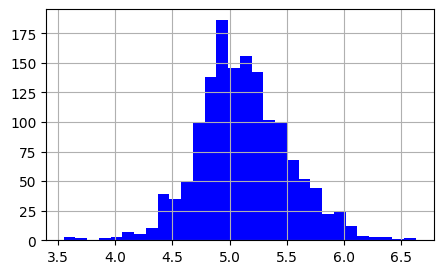

In [14]:
# Create figure
fig, axes = plt.subplots(figsize=(5, 3))

log_target_stats = view_stats(data=full_training[log_target_name], axes=axes)

This is good: it seems the log-transformed price is somewhat normally distributed, meaning it follows nice statistics for modeling.

Let's now move on to some of the other features.

### Feature analysis

We will now spend some time understanding the features of the data.

#### Missing data

We start by understanding how much data we are missing in our features.

In [15]:
feats_with_missing_data = {}

for col in full_training.columns:
    if col == target_name or col == log_target_name:
        continue
    missing_perc = 100. * full_training[col].isna().sum() / num_entries
    if missing_perc > 0:
        print(f"Feature '{col}' missing {missing_perc:.2f}% of data")
        feats_with_missing_data[col] = missing_perc

num_missing_feats = len(feats_with_missing_data)
print('=' * 120)
print(f'Total amount of features missing data = {num_missing_feats}')

Feature 'LotFrontage' missing 17.74% of data
Feature 'MasVnrArea' missing 0.55% of data
Feature 'GarageYrBlt' missing 5.55% of data
Total amount of features missing data = 3


We see there are some features that have missing entries. Let's see if the is a significant difference in the target distribution based on the fact that data is missing from these.

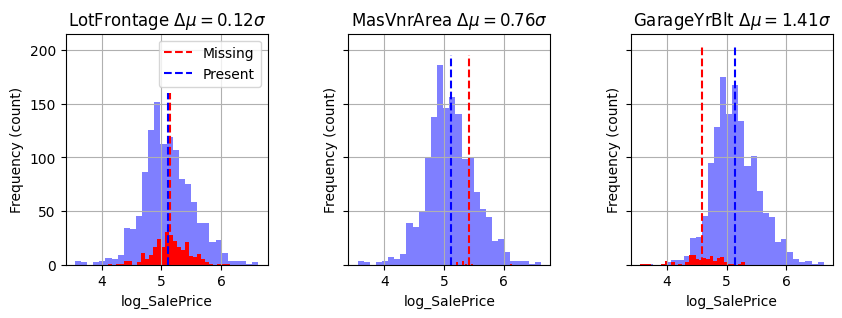

In [16]:
fig, axes = plt.subplots(1, num_missing_feats, sharey='row', figsize=(3.3 * num_missing_feats, 3))
fig.subplots_adjust(wspace=0.4)

for i, missing_feat in enumerate(list(feats_with_missing_data.keys())):
    # Set labels
    axes[i].set_ylabel('Frequency (count)')
    axes[i].set_xlabel(f'{log_target_name}')
    # Compute statistics for missing and present values
    present_stats = view_stats(data=full_training[~full_training[missing_feat].isna()][log_target_name],
                               axes=axes[i],
                               color='blue',
                               alpha=0.5,
                               verbose=False)
    missing_stats = view_stats(data=full_training[full_training[missing_feat].isna()][log_target_name],
                               axes=axes[i],
                               color='red',
                               alpha=1.,
                               verbose=False)

    # Plot the means
    ylims = axes[i].get_ylim()
    axes[i].plot([missing_stats['mean']] * 2,
                 ylims,
                 color='red',
                 linestyle='--',
                 label='Missing')
    axes[i].plot([present_stats['mean']] * 2,
                 ylims,
                 color='blue',
                 linestyle='--',
                 label='Present')

    # Set informative title
    delta_mean_rel_abs = abs(missing_stats['mean'] - present_stats['mean']) / log_target_stats['std']
    axes[i].set_title(rf'{missing_feat} $\Delta\mu=${delta_mean_rel_abs:.2f}$\sigma$')

_ = axes[0].legend()

These plots show:
1. Despite `'LotFrontage'` missing a lot of data, the missing values still somewhat follow the distribution of the general population.
2. While there are large changes in the target distribution based on the presence or absence of a `'MasVnrArea'` feature, since there are less than 10 entries missing values, it is hard to conclude any absence to be informative
3. The entries missing `'GarageYrBlt'` clearly have an impact in the target distribution, and happen often enough for that to be important. Therefore, it is likely worthwhile to add an indicator variable to help catch this.

For all three features, when training (and predicting), we will impute the median value to missing entries, but, for the specific case of `'GarageYrBlt'`, we should also add simple flag to specify whether that feature was missing or not. 

<mark>NOTE:</mark> the imputation needs to be done later, since I believe a cross-validation approach will be important, we need to make sure to use the median from the training set, not the full dataset!

#### Continuous features

Let's start our analysis with the continuous features first.

First, consider the features with highest degree of correlation with our target.

In [17]:
correlations = np.corrcoef(
    full_training[features_info['continuous']].fillna(full_training[features_info['continuous']].median()),
    full_training[log_target_name].to_numpy(),
    rowvar=False)

Now, let's order these features based on how strongly they correlate with the target variable.

In [18]:
continuous_feature_names = np.array(features_info['continuous'])

# See how to sort the correlations
corr_sort_idx = np.argsort(abs(correlations[:-1, -1]))[::-1]

continuous_feature_names = continuous_feature_names[corr_sort_idx]

Let's now plot the relationship between the top correlated features and the target. 

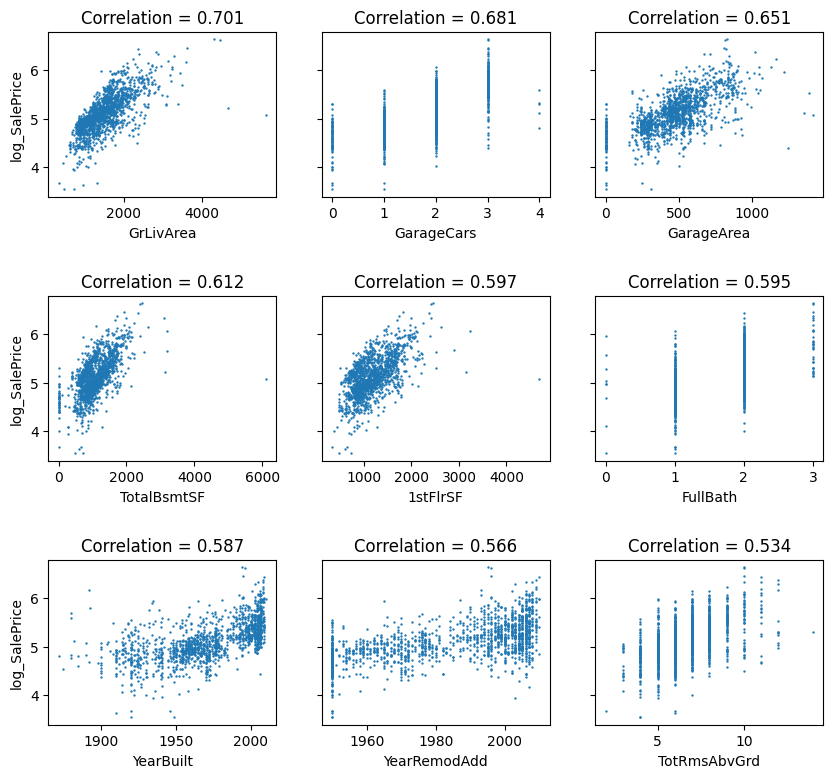

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(10, 9), sharey='all')
fig.subplots_adjust(hspace=0.6)

for i, (ind, feat_name) in enumerate(zip(corr_sort_idx[:9], continuous_feature_names[:9])):
    # Get correlation value
    correlation = correlations[ind, -1]

    # Plot
    row = i // 3
    col = i % 3
    axes[row, col].scatter(full_training[feat_name], full_training[log_target_name],
                           marker='.', s=2)

    # Set labels and title
    axes[row, col].set_xlabel(feat_name)
    if col == 0:
        axes[row, col].set_ylabel(log_target_name)
    axes[row, col].set_title(f'Correlation = {correlation:.3f}')


Let's also take a look at how these features are correlated with one another.

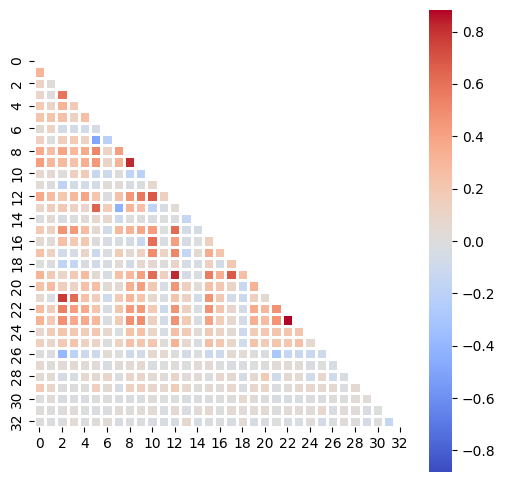

In [56]:
import seaborn

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlations[:-1, :-1], dtype=bool))

# Compute max absolute correlation
max_abs_cross_corr = abs(correlations[:-1, :-1][~mask]).max()

fig, axes = plt.subplots(figsize=(6, 6))

_ = seaborn.heatmap(
    correlations[:-1, :-1],  # The correlation matrix data
    mask=mask,  # Plot only the bottom
    annot=False,  # Add correlation values to the cells
    cmap="coolwarm",  # Choose a color map (e.g., "coolwarm", "viridis", "rocket")
    fmt=".2f",  # Format the annotations to 2 decimal places
    linewidths=1., # Add small gaps between cells
    square=True,  # Ensure the cells are square
    center=0,
    vmax=max_abs_cross_corr,
    vmin=-max_abs_cross_corr,
    ax=axes
)

We can see here that there are some features with high degree of correlation. This will be important when modeling. For now, let's just see some of them.

In [61]:
for i in range(len(continuous_feature_names)):
    for j in range(i+1, len(continuous_feature_names)):
        corr = correlations[i, j]
        if abs(corr) > 0.7:
            print(f'Correlation {continuous_feature_names[i]} -- {continuous_feature_names[j]}: {corr:.2f}')

Correlation GarageArea -- BedroomAbvGr: 0.78
Correlation TotRmsAbvGrd -- GarageYrBlt: 0.82
Correlation BsmtFinSF1 -- BsmtFullBath: 0.83
Correlation EnclosedPorch -- KitchenAbvGr: 0.88


Another good check to do here is to see if the variance of our target changes too much based on the feature value (basically, we are checking for homoskedasticity). We could do so by fitting a LOWESS curve (Locally Weighted Scatterplot Smoothing) curve and seeing if the residuals are change considerably as the value of the feature changes. However, for simplicity, what I will do here is just separate the data in quantiles and make a bar-plot of the target values.

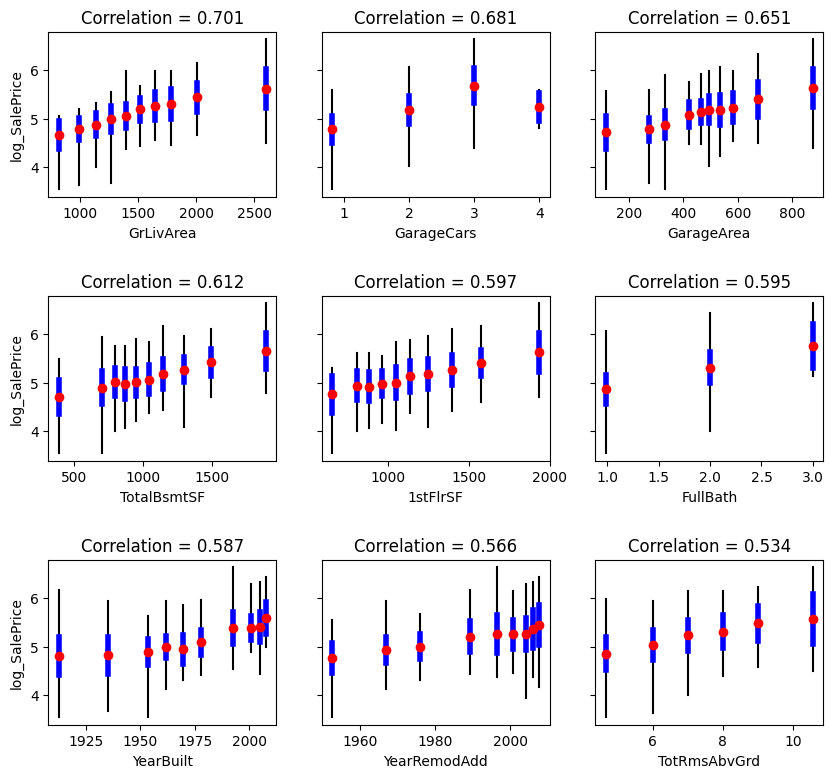

In [78]:
# Specify the quantiles to be used
quantiles = 10

fig, axes = plt.subplots(3, 3, figsize=(10, 9), sharey='all')
fig.subplots_adjust(hspace=0.6)

for i, (ind, feat_name) in enumerate(zip(corr_sort_idx[:9], continuous_feature_names[:9])):
    # Get correlation value
    correlation = correlations[ind, -1]

    # Get relevant data
    data_subset = full_training[[feat_name, log_target_name]].copy()
    data_subset['quantile_bins'] = pd.qcut(data_subset[feat_name], q=quantiles, duplicates='drop')
    # Aggregate info
    grouped = data_subset.groupby('quantile_bins', observed=False)[log_target_name].agg(['mean', 'std', 'max', 'min'])
    centers = data_subset.groupby('quantile_bins', observed=False)[feat_name].mean()

    # Plot
    row = i // 3
    col = i % 3
    for center, quantile_info in zip(centers, grouped.itertuples()):
        # Min-max (omitting for better visualization)
        axes[row, col].plot([center] * 2,
                            [quantile_info.max, quantile_info.min],
                            color='k',
                            zorder=0)

        # Mean +/- Std
        axes[row, col].plot([center] * 2,
                            [quantile_info.mean - quantile_info.std, quantile_info.mean + quantile_info.std],
                            color='blue',
                            linewidth=4,
                            zorder=1)

        # Just the mean
        axes[row, col].scatter([center], [quantile_info.mean],
                               color='red',
                               marker='o',
                               zorder=2)

    # Set labels and title
    axes[row, col].set_xlabel(feat_name)
    if col == 0:
        axes[row, col].set_ylabel(log_target_name)
    axes[row, col].set_title(f'Correlation = {correlation:.3f}')

Overall, we see that
1. There are some strong relationships between our taget variable and some of the continuous features we have.
2. The target value appears relatively well behaved (homoskedastic) when investigated under the 9 top correlated features
3. However, we also saw strong degrees of cross-correlation between features, so we need to keep that in mind for later steps!